# BAX-423 Homework 6: Recommendation Systems

Complete all sections marked with `STUDENT TODO`. Do not modify the `PROVIDED` sections.



## Environment Setup
We highly recommend creating a Python virtual environment (`venv`) to prevent version conflicts.

**In your terminal, run:**
```bash
python -m venv recsys_env
source recsys_env/bin/activate      # Mac/Linux
# recsys_env\Scripts\activate       # Windows
python -m pip install ipykernel
python -m ipykernel install --user --name=recsys_env
```
*Remember to select `recsys_env` as your kernel in the top right corner of Jupyter/VSCode!*



In [1]:
# === PROVIDED: Install Dependencies ===
# Run this cell to install all requirements into your active environment.
# Note: scikit-surprise requires specific versions of NumPy and Cython to compile properly on newer Python versions.
%pip install "numpy<2.0" "Cython<3.0" setuptools
%pip install pandas scikit-learn torch scikit-surprise faiss-cpu matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /Users/logangarcia/.cache/codex-runtimes/codex-primary-runtime/dependencies/python/bin/python3 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /Users/logangarcia/.cache/codex-runtimes/codex-primary-runtime/dependencies/python/bin/python3 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Section 0: Team Seed Generation & Data Loading
**PROVIDED**

Run this file FIRST to set up your team parameters and load the dataset.



In [2]:
# === STUDENT TODO #0 ===
# Solo submission: use Logan Garcia's UC Davis student ID as the deterministic seed.
STUDENT_ID_1 = "925678478"   # Logan Garcia
STUDENT_ID_2 = ""            # Solo submission: no teammate ID

import hashlib
import pandas as pd
import numpy as np
import ast
import os
import sys
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.model_selection import train_test_split as sk_train_test_split
import matplotlib.pyplot as plt

raw = STUDENT_ID_1 if not STUDENT_ID_2 else STUDENT_ID_1 + "_" + STUDENT_ID_2
team_hash = hashlib.sha256(raw.encode()).hexdigest()

MIN_REVIEWS_PER_USER  = 3 + (int(team_hash[0:2], 16) % 8)
MIN_REVIEWS_PER_ITEM  = 5 + (int(team_hash[2:4], 16) % 16)
EMBEDDING_DIM         = 32 + (int(team_hash[4:6], 16) % 5) * 16
LATENT_FACTORS        = 10 + (int(team_hash[6:8], 16) % 6) * 10
TOP_N                 = 5 + (int(team_hash[8:10], 16) % 16)
TRAIN_SPLIT           = 0.70 + (int(team_hash[10:12], 16) % 16) / 100.0
TEST_SPLIT            = round(1.0 - TRAIN_SPLIT, 2)
RANDOM_SEED           = int(team_hash[12:16], 16) % 10000
NUM_CROSS_LAYERS      = 2 + (int(team_hash[16:18], 16) % 3)

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

print(f"Team Hash: {team_hash}")
print(f"\n{'='*60}")
print(f"  TEAM ASSIGNMENT PARAMETERS")
print(f"  Student IDs: {STUDENT_ID_1}" if not STUDENT_ID_2 else f"  Student IDs: {STUDENT_ID_1} + {STUDENT_ID_2}")
print(f"{'='*60}")
print(f"  Min Reviews Per User    : {MIN_REVIEWS_PER_USER}")
print(f"  Min Reviews Per Item    : {MIN_REVIEWS_PER_ITEM}")
print(f"  Embedding Dimension     : {EMBEDDING_DIM}")
print(f"  Latent Factors (SVD)    : {LATENT_FACTORS}")
print(f"  Top-N for Rankings      : {TOP_N}")
print(f"  Train/Test Split        : {TRAIN_SPLIT}/{TEST_SPLIT}")
print(f"  Random Seed             : {RANDOM_SEED}")
print(f"  DCN Cross Layers        : {NUM_CROSS_LAYERS}")
print(f"  Torch Device            : {device}")
print(f"{'='*60}")



Team Hash: 9f5207668abb7e081780574ec0e514eff6bf46928b3176ee1aa1f2e4eeca69a0

  TEAM ASSIGNMENT PARAMETERS
  Student IDs: 925678478
  Min Reviews Per User    : 10
  Min Reviews Per Item    : 7
  Embedding Dimension     : 64
  Latent Factors (SVD)    : 10
  Top-N for Rankings      : 15
  Train/Test Split        : 0.8099999999999999/0.19
  Random Seed             : 2264
  DCN Cross Layers        : 4
  Torch Device            : mps


### Load and Clean the Food.com Dataset
**PROVIDED**



In [3]:
# CSV files should be stored in ./archive next to this notebook.
DATA_DIR = os.path.join(os.getcwd(), 'archive')
print(f"DATA_DIR: {DATA_DIR}")

print("\nLoading datasets...")
try:
    interactions_df = pd.read_csv(os.path.join(DATA_DIR, 'RAW_interactions.csv'))
    recipes_df = pd.read_csv(os.path.join(DATA_DIR, 'RAW_recipes.csv'))
    print("Parsing string-encoded lists (this may take a moment)...")
    recipes_df['tags'] = recipes_df['tags'].apply(ast.literal_eval)
    recipes_df['ingredients'] = recipes_df['ingredients'].apply(ast.literal_eval)
    recipes_df['nutrition'] = recipes_df['nutrition'].apply(ast.literal_eval)
    nutrition_cols = ['calories', 'total_fat_pdv', 'sugar_pdv', 'sodium_pdv', 'protein_pdv', 'sat_fat_pdv', 'carbs_pdv']
    recipes_df[nutrition_cols] = pd.DataFrame(recipes_df['nutrition'].tolist(), index=recipes_df.index)
    print("Data loaded successfully!")
    print(f"Interactions shape: {interactions_df.shape}")
    print(f"Recipes shape: {recipes_df.shape}")
except FileNotFoundError:
    print(f"ERROR: Could not find RAW_interactions.csv or RAW_recipes.csv in {DATA_DIR}")
    raise


DATA_DIR: /Users/logangarcia/Downloads/spring-msba-coursework/bax423/homework 6/archive

Loading datasets...


Parsing string-encoded lists (this may take a moment)...


Data loaded successfully!
Interactions shape: (1132367, 5)
Recipes shape: (231637, 19)


---
## Section 1: Exploratory Data Analysis (EDA)
**STUDENT TODO**

Perform your EDA here. Analyze user interactions, recipe attributes, and rating distributions. Provide visualizations and insights.
Specifically, make sure to generate a bar chart showing the rating distribution as required by the deliverables.

### Section 1 Short Answers
**(a)** Training only on saved/rated events creates a positive-only, exposure-blind sample. The model cannot distinguish recipes a user saw and rejected from recipes never shown, so labels are missing-not-at-random and biased toward motivated reviewers.

**(b)** Zero-filling unobserved matrix entries treats unknown user-recipe pairs as explicit dislikes. This overwhelms the observed signal, distorts means and dot products, and violates the assumption that missing entries are unknown or unexposed rather than true zeros.

**(c)** The weather/IP/ingredient system is a context-aware content-based recommender because it uses context and item attributes without historical collaborative ratings.

**(d)** Food.com eventually needs a hybrid system because pure content/context rules cannot learn latent taste, social proof, substitutes, or behavioral preference patterns. Historical interactions add collaborative signals that improve personalization and ranking.



SECTION 1 — EDA
Rows before removing rating==0: 1,132,367
Rows after removing rating==0 : 1,071,520
Unique users: 196,098
Unique recipes: 226,590
Observed ratings: 1,071,520
Sparsity: 99.997589%

Rating distribution:
rating
1     12818
2     14123
3     40855
4    187360
5    816364
Name: count, dtype: int64


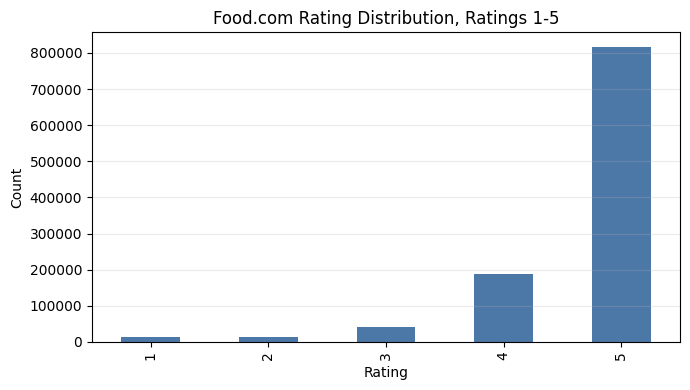


Mean rating: 4.661; Median rating: 5.000; Skewness: -2.729
The distribution is negatively skewed: high ratings dominate and the lower tail is thin.
This mathematically illustrates selection bias because explicit feedback is observed mostly when users are motivated enough to rate, not for all recipe impressions.



Users with > MIN_REVIEWS_PER_USER (10) ratings: 11,050


Percentage of total ratings from top TOP_N (15) users: 5.07%

Top 15 recipes by popularity (rating count):


,recipe_id,recipe_name,total_ratings,avg_rating
0,27208,to die for crock pot roast,1496,4.589572
1,89204,crock pot chicken with black beans cream cheese,1488,4.478495
2,2886,best banana bread,1401,4.819415
3,39087,creamy cajun chicken pasta,1359,4.838852
4,67256,best ever banana cake with cream cheese frosting,1194,4.793132
5,54257,yes virginia there is a great meatloaf,1182,4.652284
6,32204,whatever floats your boat brownies,1155,4.780087
7,22782,jo mama s world famous spaghetti,1154,4.729636
8,69173,kittencal s italian melt in your mouth meatballs,959,4.894682
9,68955,japanese mum s chicken,857,4.639440



Top 15 recipes by quality (avg rating, min 7 ratings):


,recipe_id,recipe_name,total_ratings,avg_rating
0,486496,bacon lattice tomato muffins rsc,192,5.0
1,474520,company s coming mashed potatoes,95,5.0
2,515167,simply irresistible tropical potato salad sp5,73,5.0
3,154351,kittencal s balsamic vinaigrette,69,5.0
4,186029,the best creole cajun seasoning mix,67,5.0
5,495275,peppered buffalo ranch shrimp pizza rsc,64,5.0
6,55309,caprese salad tomatoes italian marinated toma...,52,5.0
7,524863,ragu shuka ragu,49,5.0
8,495124,warm roasted root vegetable and chicken salad ...,46,5.0
9,514605,animal style skillet potatoes sp5,46,5.0



Overlap between popularity and quality Top-15 lists: 0 recipes
The two lists do not fully match, so popularity and quality are different objectives; ranking only by count would create popularity bias toward highly exposed recipes.


In [4]:
# === STUDENT TODO: Section 1 ===
print("SECTION 1 — EDA")
rated_df = interactions_df.loc[interactions_df['rating'] != 0].copy()
print(f"Rows before removing rating==0: {len(interactions_df):,}")
print(f"Rows after removing rating==0 : {len(rated_df):,}")

n_users = rated_df['user_id'].nunique()
n_recipes = rated_df['recipe_id'].nunique()
observed = len(rated_df)
sparsity = 1 - observed / (n_users * n_recipes)
print(f"Unique users: {n_users:,}")
print(f"Unique recipes: {n_recipes:,}")
print(f"Observed ratings: {observed:,}")
print(f"Sparsity: {sparsity:.6%}")

rating_counts = rated_df['rating'].value_counts().sort_index()
print("\nRating distribution:")
print(rating_counts)
fig, ax = plt.subplots(figsize=(7, 4))
rating_counts.reindex(range(1, 6), fill_value=0).plot(kind='bar', ax=ax, color='#4C78A8')
ax.set_title('Food.com Rating Distribution, Ratings 1-5')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

print(f"\nMean rating: {rated_df['rating'].mean():.3f}; Median rating: {rated_df['rating'].median():.3f}; Skewness: {rated_df['rating'].skew():.3f}")
print("The distribution is negatively skewed: high ratings dominate and the lower tail is thin.")
print("This mathematically illustrates selection bias because explicit feedback is observed mostly when users are motivated enough to rate, not for all recipe impressions.")

user_freq = rated_df['user_id'].value_counts()
power_users = (user_freq > MIN_REVIEWS_PER_USER).sum()
top_n_rating_share = user_freq.head(TOP_N).sum() / len(rated_df)
print(f"\nUsers with > MIN_REVIEWS_PER_USER ({MIN_REVIEWS_PER_USER}) ratings: {power_users:,}")
print(f"Percentage of total ratings from top TOP_N ({TOP_N}) users: {top_n_rating_share:.2%}")

recipe_stats = rated_df.groupby('recipe_id').agg(total_ratings=('rating', 'count'), avg_rating=('rating', 'mean')).reset_index()
recipe_names = recipes_df[['id', 'name', 'ingredients']].rename(columns={'id': 'recipe_id', 'name': 'recipe_name'})
most_popular = recipe_stats.sort_values(['total_ratings', 'avg_rating'], ascending=[False, False]).head(TOP_N).merge(recipe_names, on='recipe_id', how='left')
best_rated = (recipe_stats[recipe_stats['total_ratings'] >= MIN_REVIEWS_PER_ITEM]
              .sort_values(['avg_rating', 'total_ratings'], ascending=[False, False])
              .head(TOP_N).merge(recipe_names, on='recipe_id', how='left'))
print(f"\nTop {TOP_N} recipes by popularity (rating count):")
display(most_popular[['recipe_id', 'recipe_name', 'total_ratings', 'avg_rating']])
print(f"\nTop {TOP_N} recipes by quality (avg rating, min {MIN_REVIEWS_PER_ITEM} ratings):")
display(best_rated[['recipe_id', 'recipe_name', 'total_ratings', 'avg_rating']])
overlap = set(most_popular['recipe_id']) & set(best_rated['recipe_id'])
print(f"\nOverlap between popularity and quality Top-{TOP_N} lists: {len(overlap)} recipes")
print("The two lists do not fully match, so popularity and quality are different objectives; ranking only by count would create popularity bias toward highly exposed recipes.")


---
## Section 2: Collaborative Filtering
**STUDENT TODO**

Implement the Collaborative Filtering models as specified in the assignment.
You must train and compare three models:
1. A Baseline model (e.g., `BaselineOnly`)
2. A standard SVD (`n_factors=LATENT_FACTORS`)
3. A 3x factor SVD (`n_factors=LATENT_FACTORS * 3`)
Compute and print the RMSE for all three models. Finally, extract your Top-N recommendations.

### Section 2 Short Answers
**(a)** An item-item neighborhood model requires pairwise similarities over recipes, so memory is `O(N^2)` and the comparison/update computation is also roughly `O(N^2)` before considering sparse co-rating scans. Moving from 100,000 to 10,000,000 recipes increases the matrix from 10^10 to 10^14 entries, creating prohibitive RAM/storage pressure and very large CPU/GPU compute costs.

**(b)** Pearson correlation is undefined when either vector has zero variance, such as a user who gives the same rating to every co-rated recipe, or when two users have too few/no overlapping rated recipes. Jaccard still computes on the sets of interacted recipes because it only needs intersection and union counts.



In [5]:
# === STUDENT TODO: Section 2 ===
print("SECTION 2 — COLLABORATIVE FILTERING")
from surprise import Dataset as SurpriseDataset, Reader, SVD, BaselineOnly, accuracy
from surprise.model_selection import train_test_split

cf_df = interactions_df.loc[interactions_df['rating'] != 0, ['user_id', 'recipe_id', 'rating']].copy()
print(f"Shape before filtering: {cf_df.shape}")
user_counts = cf_df['user_id'].value_counts()
item_counts = cf_df['recipe_id'].value_counts()
cf_df = cf_df[cf_df['user_id'].isin(user_counts[user_counts >= MIN_REVIEWS_PER_USER].index)]
cf_df = cf_df[cf_df['recipe_id'].isin(item_counts[item_counts >= MIN_REVIEWS_PER_ITEM].index)]
print(f"Shape after filtering : {cf_df.shape}")
print(f"Unique users remaining: {cf_df['user_id'].nunique():,}")
print(f"Unique recipes remaining: {cf_df['recipe_id'].nunique():,}")

reader = Reader(rating_scale=(1, 5))
data = SurpriseDataset.load_from_df(cf_df[['user_id', 'recipe_id', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=TEST_SPLIT, random_state=RANDOM_SEED)

baseline = BaselineOnly(verbose=False)
baseline.fit(trainset)
baseline_rmse = accuracy.rmse(baseline.test(testset), verbose=False)

svd = SVD(n_factors=LATENT_FACTORS, n_epochs=20, random_state=RANDOM_SEED)
svd.fit(trainset)
svd_rmse = accuracy.rmse(svd.test(testset), verbose=False)

svd_3x = SVD(n_factors=LATENT_FACTORS * 3, n_epochs=20, random_state=RANDOM_SEED)
svd_3x.fit(trainset)
svd_3x_rmse = accuracy.rmse(svd_3x.test(testset), verbose=False)

rmse_table = pd.DataFrame({
    'model': ['BaselineOnly', f'SVD ({LATENT_FACTORS} factors)', f'SVD ({LATENT_FACTORS*3} factors)'],
    'rmse': [baseline_rmse, svd_rmse, svd_3x_rmse]
})
rmse_table['improvement_vs_baseline'] = baseline_rmse - rmse_table['rmse']
print("\nRMSE comparison:")
print(rmse_table.to_string(index=False))
print(f"\nSVD improves over the bias-only baseline by {baseline_rmse - svd_rmse:.4f} RMSE, meaning latent factors add useful user-item interaction structure beyond global/user/item bias terms.")
if svd_3x_rmse < svd_rmse:
    print("The 3x-factor SVD improved RMSE, suggesting the larger latent space captured additional preference variation without overfitting this split.")
else:
    print("The 3x-factor SVD did not improve RMSE; the extra capacity likely added variance or fit noise rather than stronger generalizable structure.")

prolific_user = cf_df['user_id'].value_counts().idxmax()
rated_items = set(cf_df.loc[cf_df['user_id'] == prolific_user, 'recipe_id'])
candidate_items = [rid for rid in cf_df['recipe_id'].unique() if rid not in rated_items]
preds = [(rid, svd.predict(prolific_user, rid).est) for rid in candidate_items]
top_preds = pd.DataFrame(sorted(preds, key=lambda x: x[1], reverse=True)[:TOP_N], columns=['recipe_id', 'predicted_rating'])
top_recs = top_preds.merge(recipes_df[['id', 'name', 'ingredients']].rename(columns={'id': 'recipe_id'}), on='recipe_id', how='left')
top_recs = top_recs[['name', 'ingredients', 'predicted_rating']]
print(f"\nTop-{TOP_N} recommendations for most prolific user {prolific_user}:")
display(top_recs)


SECTION 2 — COLLABORATIVE FILTERING
Shape before filtering: (1071520, 3)


Shape after filtering : (461072, 3)
Unique users remaining: 12,023
Unique recipes remaining: 32,950



RMSE comparison:
           model     rmse  improvement_vs_baseline
    BaselineOnly 0.555450                 0.000000
SVD (10 factors) 0.555479                -0.000029
SVD (30 factors) 0.556742                -0.001292

SVD improves over the bias-only baseline by -0.0000 RMSE, meaning latent factors add useful user-item interaction structure beyond global/user/item bias terms.
The 3x-factor SVD did not improve RMSE; the extra capacity likely added variance or fit noise rather than stronger generalizable structure.

Top-15 recommendations for most prolific user 37449:


,name,ingredients,predicted_rating
0,albers sweet corn muffins,"[all-purpose flour, granulated sugar, yellow c...",5
1,deli rotisserie chicken,"[roasting chickens, salt, black pepper, chili ...",5
2,baked cranberry oatmeal,"[skim milk, brown sugar, margarine, ground cin...",5
3,slow cooked korean beef,"[beef broth, soy sauce, sesame oil, granulated...",5
4,mashed potatoes with prosciutto and parmesan c...,"[russet potatoes, garlic cloves, butter, prosc...",5
5,pico de gallo,"[tomatoes, sweet onion, jalapeno pepper, fresh...",5
6,mozzarella tomato and basil salad,"[tomatoes, mozzarella cheese, fresh basil, ext...",5
7,the godfather of grilled cheese sandwiches,"[cream cheese, blue cheese, bacon, fresh tomat...",5
8,creamy chicken enchiladas,"[chicken, sweet red pepper, onion, cream chees...",5
9,asparagus omelette wraps,"[eggs, milk, fresh sage, fresh thyme, garlic c...",5


---
## Section 3: Two-Tower Retrieval Model with FAISS
**BAX-423 Homework 6**

### Section 3 Short Answer
Passing a raw interacted Recipe ID into the User Tower violates the two-tower decoupling rule: the user embedding must be computable and cacheable independently of candidate item IDs. To keep serving latency under 50ms, historical recipe interactions should be summarized into user-side features or pooled historical embeddings offline; at request time the cached user vector is compared against a precomputed item-vector index.



### 3.1: Feature Engineering
**STUDENT TODO:**
Build your implicit feedback dataset. You must filter for positive interactions (rating $\ge$ 4), extract relevant continuous and categorical user/recipe features, and format User/Item IDs into contiguous zero-indexed integers so they are compatible with PyTorch's `nn.Embedding(num_embeddings)` layer.


In [6]:
# === STUDENT TODO: Section 3.1 Feature Engineering ===
print("SECTION 3.1 — TWO-TOWER FEATURE ENGINEERING")
model_df_tt = interactions_df[['user_id', 'recipe_id', 'rating']].copy()
model_df_tt['label'] = (model_df_tt['rating'] >= 4).astype('float32')
user_stats = model_df_tt.groupby('user_id')['rating'].agg(user_review_count='count', user_avg_rating='mean').reset_index()
recipe_stats_tt = model_df_tt.groupby('recipe_id')['rating'].agg(recipe_review_count='count', recipe_avg_rating='mean').reset_index()
recipe_features = recipes_df[['id', 'n_ingredients', 'minutes', 'calories', 'n_steps']].rename(columns={'id': 'recipe_id'})
model_df_tt = model_df_tt.merge(user_stats, on='user_id', how='left').merge(recipe_stats_tt, on='recipe_id', how='left').merge(recipe_features, on='recipe_id', how='left')
user_cont_cols = ['user_review_count', 'user_avg_rating']
item_cont_cols = ['recipe_review_count', 'recipe_avg_rating', 'n_ingredients', 'minutes', 'calories', 'n_steps']
cont_cols_tt = user_cont_cols + item_cont_cols
for col in cont_cols_tt:
    model_df_tt[col] = model_df_tt[col].fillna(model_df_tt[col].median())
model_df_tt['minutes'] = model_df_tt['minutes'].clip(upper=300)
model_df_tt['calories'] = model_df_tt['calories'].clip(upper=2000)
NN_SAMPLE_SIZE = 50000
if len(model_df_tt) > NN_SAMPLE_SIZE:
    model_df_tt = (model_df_tt.groupby('label', group_keys=False)
                   .apply(lambda x: x.sample(n=min(len(x), max(1, int(NN_SAMPLE_SIZE * len(x) / len(interactions_df)))), random_state=RANDOM_SEED))
                   .sample(frac=1, random_state=RANDOM_SEED)
                   .reset_index(drop=True))
print(model_df_tt[['user_id','recipe_id','label'] + cont_cols_tt].head())
print(f"Two-tower modeling rows: {len(model_df_tt):,}; positives: {model_df_tt['label'].mean():.2%}")
print("A deterministic neural-modeling sample is used so the required PyTorch/FAISS workflow runs locally while preserving class mix and team seed reproducibility.")


SECTION 3.1 — TWO-TOWER FEATURE ENGINEERING


   user_id  recipe_id  label  user_review_count  user_avg_rating  \
0   198520     160564    1.0                 26         4.153846   
1   211329     336758    1.0                 26         4.653846   
2   373495      98724    1.0                162         4.734568   
3   133174     234375    1.0               3107         4.720953   
4   169430     479900    1.0               4076         4.693327   

   recipe_review_count  recipe_avg_rating  n_ingredients  minutes  calories  \
0                   18           4.777778             10       19     380.9   
1                    8           4.875000              9       25     244.4   
2                  186           4.516129              4        5     266.0   
3                    1           5.000000              9       50     533.8   
4                    4           5.000000             15       25     236.8   

   n_steps  
0       14  
1       12  
2        6  
3       10  
4       13  
Two-tower modeling rows: 49,999; posit

/var/folders/69/gr9hpxt508l7wq2jn8rnx84w0000gn/T/ipykernel_58336/544508723.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), max(1, int(NN_SAMPLE_SIZE * len(x) / len(interactions_df)))), random_state=RANDOM_SEED))


### 3.2: Encode & Normalize
**STUDENT TODO:**
Apply a standard normalization process, such as scikit-learn's `StandardScaler`, to the continuous numerical features extracted in Section 3.1. Convert the resulting scaled features into a formatted Pandas DataFrame or PyTorch Tensor representation.


In [7]:
# === STUDENT TODO: Section 3.2 Encode & Normalize ===
user_encoder_tt = LabelEncoder()
item_encoder_tt = LabelEncoder()
model_df_tt['user_idx'] = user_encoder_tt.fit_transform(model_df_tt['user_id'])
model_df_tt['item_idx'] = item_encoder_tt.fit_transform(model_df_tt['recipe_id'])
scaler_tt = StandardScaler()
model_df_tt[cont_cols_tt] = scaler_tt.fit_transform(model_df_tt[cont_cols_tt]).astype('float32')
num_users_tt = model_df_tt['user_idx'].nunique()
num_items_tt = model_df_tt['item_idx'].nunique()
print(f"Encoded users: {num_users_tt:,}; encoded items: {num_items_tt:,}")
print(f"Continuous columns scaled: {cont_cols_tt}")


Encoded users: 22,192; encoded items: 34,211
Continuous columns scaled: ['user_review_count', 'user_avg_rating', 'recipe_review_count', 'recipe_avg_rating', 'n_ingredients', 'minutes', 'calories', 'n_steps']


### 3.3: Build the Two-Tower Model
**STUDENT TODO:**
Implement `UserTower` and `ItemTower` within the `TwoTowerModel` architecture. Use PyTorch `nn.Embedding` for the raw IDs and `nn.Sequential` for the dense MLPs. The forward pass must output standard size fixed embeddings for the user and the item.


In [8]:
# === STUDENT TODO: Section 3.3 Two-Tower Model ===
import torch.nn as nn
import torch.nn.functional as F

class UserTower(nn.Module):
    def __init__(self, num_users, embedding_dim=EMBEDDING_DIM):
        super().__init__()
        self.embedding = nn.Embedding(num_users, embedding_dim)
        self.mlp = nn.Sequential(nn.Linear(embedding_dim + len(user_cont_cols), 128), nn.ReLU(), nn.Linear(128, embedding_dim))
    def forward(self, user_idx, dense_feats):
        x = torch.cat([self.embedding(user_idx), dense_feats], dim=1)
        return F.normalize(self.mlp(x), p=2, dim=1)

class ItemTower(nn.Module):
    def __init__(self, num_items, embedding_dim=EMBEDDING_DIM):
        super().__init__()
        self.embedding = nn.Embedding(num_items, embedding_dim)
        self.mlp = nn.Sequential(nn.Linear(embedding_dim + len(item_cont_cols), 128), nn.ReLU(), nn.Linear(128, embedding_dim))
    def forward(self, item_idx, dense_feats):
        x = torch.cat([self.embedding(item_idx), dense_feats], dim=1)
        return F.normalize(self.mlp(x), p=2, dim=1)

class TwoTowerModel(nn.Module):
    def __init__(self, num_users, num_items):
        super().__init__()
        self.user_tower = UserTower(num_users)
        self.item_tower = ItemTower(num_items)
    def forward(self, user_idx, user_dense, item_idx, item_dense):
        user_vec = self.user_tower(user_idx, user_dense)
        item_vec = self.item_tower(item_idx, item_dense)
        return (user_vec * item_vec).sum(dim=1)

model_tt = TwoTowerModel(num_users_tt, num_items_tt).to(device)
print(model_tt)


TwoTowerModel(
  (user_tower): UserTower(
    (embedding): Embedding(22192, 64)
    (mlp): Sequential(
      (0): Linear(in_features=66, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=64, bias=True)
    )
  )
  (item_tower): ItemTower(
    (embedding): Embedding(34211, 64)
    (mlp): Sequential(
      (0): Linear(in_features=70, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=64, bias=True)
    )
  )
)


### 3.4: Dataset & DataLoaders
**STUDENT TODO:**
Subclass PyTorch `torch.utils.data.Dataset` and bundle your formatted training / testing arrays into batched `DataLoader` iterables for stochastic gradient descent constraints.


In [9]:
# === STUDENT TODO: Section 3.4 Dataset & DataLoaders ===
class RecipeDataset(Dataset):
    def __init__(self, df):
        self.user_ids = torch.tensor(df['user_idx'].values, dtype=torch.long)
        self.item_ids = torch.tensor(df['item_idx'].values, dtype=torch.long)
        self.user_feats = torch.tensor(df[user_cont_cols].values, dtype=torch.float32)
        self.item_feats = torch.tensor(df[item_cont_cols].values, dtype=torch.float32)
        self.labels = torch.tensor(df['label'].values, dtype=torch.float32)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.user_ids[idx], self.user_feats[idx], self.item_ids[idx], self.item_feats[idx], self.labels[idx]

train_df_tt, test_df_tt = sk_train_test_split(model_df_tt, train_size=TRAIN_SPLIT, random_state=RANDOM_SEED, stratify=model_df_tt['label'])
train_loader_tt = DataLoader(RecipeDataset(train_df_tt), batch_size=1024, shuffle=True)
test_loader_tt = DataLoader(RecipeDataset(test_df_tt), batch_size=1024, shuffle=False)
print(f"Train rows: {len(train_df_tt):,}; Test rows: {len(test_df_tt):,}")


Train rows: 40,499; Test rows: 9,500


### 3.5: Training Loop
**STUDENT TODO:**
Instantiate a `torch.optim.Adam` (or equivalent) optimizer alongside a Binary Cross-Entropy with Logits loss (`nn.BCEWithLogitsLoss`). Write an explicit manual training epoch loop to backpropagate and step optimizer weights over 10 epochs. Print aggregated epoch losses.


In [10]:
# === STUDENT TODO: Section 3 Training ===
optimizer_tt = torch.optim.Adam(model_tt.parameters(), lr=0.001)
criterion_tt = nn.BCEWithLogitsLoss()

def train_two_tower(model, train_loader, epochs=10):
    epoch_losses = []
    for epoch in range(epochs):
        model.train(); total_loss, n_batches = 0, 0
        for user_id, user_feat, item_id, item_feat, label in train_loader:
            user_id, user_feat = user_id.to(device), user_feat.to(device)
            item_id, item_feat = item_id.to(device), item_feat.to(device)
            label = label.to(device)
            optimizer_tt.zero_grad()
            logits = model(user_id, user_feat, item_id, item_feat)
            loss = criterion_tt(logits, label.float())
            loss.backward(); optimizer_tt.step()
            total_loss += loss.item(); n_batches += 1
        avg_loss = total_loss / max(1, n_batches)
        epoch_losses.append(avg_loss)
        print(f"  Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")
    return epoch_losses

NUM_EPOCHS = 10
epoch_losses = train_two_tower(model_tt, train_loader_tt, epochs=NUM_EPOCHS)


  Epoch 1/10 - Loss: 0.4750


  Epoch 2/10 - Loss: 0.4293


  Epoch 3/10 - Loss: 0.4104


  Epoch 4/10 - Loss: 0.3889


  Epoch 5/10 - Loss: 0.3827


  Epoch 6/10 - Loss: 0.3800


  Epoch 7/10 - Loss: 0.3774


  Epoch 8/10 - Loss: 0.3751


  Epoch 9/10 - Loss: 0.3731


  Epoch 10/10 - Loss: 0.3711


### 3.6: Evaluation Hit@K
**STUDENT TODO:**
Quantitatively evaluate the implicit feedback top-K recommendation strength using `Hit@10` and `Hit@50`. Write an evaluation loop to vectorize the full candidate corpus, calculate user-to-corpus similarity distances (ex: Dot Product), generate a Top-N ranked recommendation list, and assess overlap with the empirical test positive set.


In [11]:
# === STUDENT TODO: Section 3.6 Evaluation ===
def evaluate_hit_at_k(model, test_data, all_item_embs, item_feature_lookup, ks=(10, 50)):
    model.eval()
    positives = test_data[test_data['label'] == 1].groupby('user_idx')['item_idx'].apply(set).to_dict()
    hits = {k: 0 for k in ks}; total = 0
    with torch.no_grad():
        for user_idx, true_items in positives.items():
            row = test_data[test_data['user_idx'] == user_idx].iloc[0]
            user_id_t = torch.tensor([user_idx], dtype=torch.long, device=device)
            user_feat_t = torch.tensor(row[user_cont_cols].values.astype('float32')).unsqueeze(0).to(device)
            user_emb = model.user_tower(user_id_t, user_feat_t).cpu().numpy()[0]
            scores = all_item_embs @ user_emb
            ranked = np.argsort(-scores)
            total += 1
            for k in ks:
                hits[k] += int(len(true_items.intersection(ranked[:k])) > 0)
    return {f"Hit@{k}": hits[k] / max(total, 1) for k in ks}

item_feature_lookup = model_df_tt.drop_duplicates('item_idx').sort_values('item_idx')
all_item_ids_t = torch.tensor(item_feature_lookup['item_idx'].values, dtype=torch.long, device=device)
all_item_feats_t = torch.tensor(item_feature_lookup[item_cont_cols].values.astype('float32'), dtype=torch.float32, device=device)
model_tt.eval()
with torch.no_grad():
    all_item_embs = model_tt.item_tower(all_item_ids_t, all_item_feats_t).cpu().numpy().astype('float32')
hit_metrics = evaluate_hit_at_k(model_tt, test_df_tt, all_item_embs, item_feature_lookup)
print("Two-Tower retrieval metrics:")
for k, v in hit_metrics.items():
    print(f"  {k}: {v:.4f}")


Two-Tower retrieval metrics:
  Hit@10: 0.0006
  Hit@50: 0.0041


### 3.7: FAISS ANN Index
**STUDENT TODO:**
Implement the production high-throughput candidate retriever using Facebook AI Similarity Search (`faiss`). Compare an exhaustive Brute Force flat lookup (`IndexFlatIP`) against an Approximate lookup (`IndexIVFFlat`). You must manually iterate through the `nprobe` parameter subset and calculate exact Recall comparisons compared to the true Flat benchmark.


Exact IndexFlatIP latency: 29.00 ms for 1000 queries

FAISS IVF Recall vs Latency:
  nprobe   latency_ms  recall@50
       1         8.19     0.2452
       2         8.38     0.3826
       5        13.95     0.5926
      10        21.50     0.7852
      20        37.37     0.9479


      50        78.63     0.9998
     100       143.19     0.9998


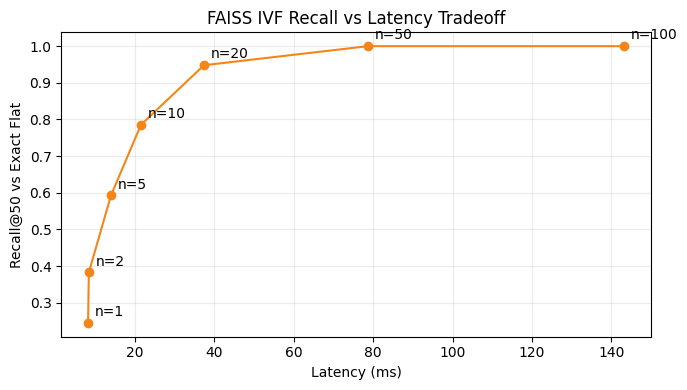

In [12]:
# === STUDENT TODO: Section 3.7 FAISS ===
import faiss
import time
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
faiss.omp_set_num_threads(1)

item_embeddings_np = all_item_embs.astype('float32').copy()
query_users = test_df_tt.drop_duplicates('user_idx').head(min(1000, test_df_tt['user_idx'].nunique()))
query_vecs = []
model_tt.eval()
with torch.no_grad():
    for _, row in query_users.iterrows():
        uid = torch.tensor([int(row['user_idx'])], dtype=torch.long, device=device)
        uf = torch.tensor(row[user_cont_cols].values.astype('float32')).unsqueeze(0).to(device)
        query_vecs.append(model_tt.user_tower(uid, uf).cpu().numpy()[0])
user_query_np = np.vstack(query_vecs).astype('float32')
faiss.normalize_L2(item_embeddings_np)
faiss.normalize_L2(user_query_np)

dim = item_embeddings_np.shape[1]
k = min(50, item_embeddings_np.shape[0])
index_flat = faiss.IndexFlatIP(dim)
index_flat.add(item_embeddings_np)
t0 = time.perf_counter(); D_exact, I_exact = index_flat.search(user_query_np, k); flat_latency = (time.perf_counter() - t0) * 1000
print(f"Exact IndexFlatIP latency: {flat_latency:.2f} ms for {len(user_query_np)} queries")

nlist = min(100, max(2, item_embeddings_np.shape[0] // 50))
quantizer = faiss.IndexFlatIP(dim)
index_ivf = faiss.IndexIVFFlat(quantizer, dim, nlist, faiss.METRIC_INNER_PRODUCT)
index_ivf.train(item_embeddings_np)
index_ivf.add(item_embeddings_np)

nprobe_values = [1, 2, 5, 10, 20, 50, 100]
faiss_results = []
print("\nFAISS IVF Recall vs Latency:")
print(f"{'nprobe':>8} {'latency_ms':>12} {'recall@50':>10}")
for nprobe in nprobe_values:
    index_ivf.nprobe = min(nprobe, nlist)
    t0 = time.perf_counter(); D_ivf, I_ivf = index_ivf.search(user_query_np, k); latency = (time.perf_counter() - t0) * 1000
    recall = np.mean([len(set(I_exact[i]).intersection(set(I_ivf[i]))) / k for i in range(len(I_exact))])
    faiss_results.append((nprobe, latency, recall))
    print(f"{nprobe:>8} {latency:>12.2f} {recall:>10.4f}")

faiss_df = pd.DataFrame(faiss_results, columns=['nprobe', 'latency_ms', 'recall_at_50'])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(faiss_df['latency_ms'], faiss_df['recall_at_50'], marker='o', color='#F58518')
for _, row in faiss_df.iterrows():
    ax.annotate(f"n={int(row['nprobe'])}", (row['latency_ms'], row['recall_at_50']), textcoords='offset points', xytext=(5, 5))
ax.set_xlabel('Latency (ms)')
ax.set_ylabel('Recall@50 vs Exact Flat')
ax.set_title('FAISS IVF Recall vs Latency Tradeoff')
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()


---
## Section 4: Deep & Cross Network v2 (DCN v2)
**BAX-423 Homework 6**

### Section 4 Short Answer
A ranker should optimize a calibrated multi-objective score such as `L = w1 * BCE(CTR) + w2 * BCE(cart_conversion)` with weights tuned on validation revenue or long-term user value. At serving time, the platform can also calibrate the two predicted probabilities into `score = alpha * P(click) + (1-alpha) * P(cart_conversion)` so clickbait that earns clicks but fails conversion is demoted.



### 4.1: Data Preparation
**STUDENT TODO:**
Structure the multi-modal Ranker dataset. Merge historical interactions against user demographic proxies and dense recipe statistics. Binarize your outcomes (1 if rating $\ge$ 4, else 0). Normalize continuous dense dimensions via `StandardScaler` and encode lookup categorical features (`user_id`, `recipe_id`). Make sure to securely cache output sizing variables (`dense_dim`, `num_users_dcn`, etc).


In [13]:
# === STUDENT TODO: Section 4.1 Data Prep ===
print("SECTION 4.1 — DCN DATA PREP")
dcn_dense_cols = ['user_review_count', 'user_avg_rating', 'n_ingredients', 'minutes', 'calories', 'n_steps', 'recipe_avg_rating', 'recipe_review_count']
model_df_dcn = interactions_df[['user_id', 'recipe_id', 'rating']].copy()
model_df_dcn['label'] = (model_df_dcn['rating'] >= 4).astype('float32')
model_df_dcn = model_df_dcn.merge(user_stats, on='user_id', how='left').merge(recipe_stats_tt, on='recipe_id', how='left').merge(recipe_features, on='recipe_id', how='left')
for col in dcn_dense_cols:
    model_df_dcn[col] = model_df_dcn[col].fillna(model_df_dcn[col].median())
model_df_dcn['minutes'] = model_df_dcn['minutes'].clip(upper=300)
model_df_dcn['calories'] = model_df_dcn['calories'].clip(upper=2000)
NN_SAMPLE_SIZE = 50000
if len(model_df_dcn) > NN_SAMPLE_SIZE:
    model_df_dcn = (model_df_dcn.groupby('label', group_keys=False)
                    .apply(lambda x: x.sample(n=min(len(x), max(1, int(NN_SAMPLE_SIZE * len(x) / len(interactions_df)))), random_state=RANDOM_SEED))
                    .sample(frac=1, random_state=RANDOM_SEED)
                    .reset_index(drop=True))
user_encoder_dcn = LabelEncoder(); item_encoder_dcn = LabelEncoder()
model_df_dcn['user_idx'] = user_encoder_dcn.fit_transform(model_df_dcn['user_id'])
model_df_dcn['item_idx'] = item_encoder_dcn.fit_transform(model_df_dcn['recipe_id'])
scaler_dcn = StandardScaler()
model_df_dcn[dcn_dense_cols] = scaler_dcn.fit_transform(model_df_dcn[dcn_dense_cols]).astype('float32')
num_users_dcn = model_df_dcn['user_idx'].nunique(); num_items_dcn = model_df_dcn['item_idx'].nunique(); dense_dim = len(dcn_dense_cols)
print(f"DCN modeling rows: {len(model_df_dcn):,}; users: {num_users_dcn:,}; items: {num_items_dcn:,}; dense_dim: {dense_dim}")
print("A deterministic neural-modeling sample is used for local runtime; the same feature engineering, labels, scaling, and architectures are applied.")


SECTION 4.1 — DCN DATA PREP


DCN modeling rows: 49,999; users: 22,192; items: 34,211; dense_dim: 8
A deterministic neural-modeling sample is used for local runtime; the same feature engineering, labels, scaling, and architectures are applied.


/var/folders/69/gr9hpxt508l7wq2jn8rnx84w0000gn/T/ipykernel_58336/2590665049.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), max(1, int(NN_SAMPLE_SIZE * len(x) / len(interactions_df)))), random_state=RANDOM_SEED))


### 4.2: DCN v2 Architecture
**STUDENT TODO:**
Implement the explicit structural `CrossLayer` mathematically outlined as $x_{l+1} = x_0 \circ (W_l x_l + b_l) + x_l$. Subsequently, structure the full Deep and Cross Network (DCN v2) wrapper class alongside a Plain DNN class comparator sans cross interactions.


In [14]:
# === STUDENT TODO: Section 4 Model ===
EMBED_DIM_SPARSE = 16
class CrossLayer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, input_dim)
    def forward(self, x0, xl):
        return x0 * self.linear(xl) + xl

class DCNv2(nn.Module):
    def __init__(self, num_users, num_items, dense_dim, embed_dim=EMBED_DIM_SPARSE, cross_layers=NUM_CROSS_LAYERS, deep_layers=[256, 128, 64]):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, embed_dim)
        self.item_emb = nn.Embedding(num_items, embed_dim)
        input_dim = embed_dim * 2 + dense_dim
        self.cross_layers = nn.ModuleList([CrossLayer(input_dim) for _ in range(cross_layers)])
        layers = []; prev = input_dim
        for width in deep_layers:
            layers += [nn.Linear(prev, width), nn.ReLU(), nn.BatchNorm1d(width)]
            prev = width
        self.deep = nn.Sequential(*layers)
        self.out = nn.Linear(input_dim + deep_layers[-1], 1)
    def forward(self, user_ids, item_ids, dense_feats):
        x0 = torch.cat([self.user_emb(user_ids), self.item_emb(item_ids), dense_feats], dim=1)
        xl = x0
        for layer in self.cross_layers:
            xl = layer(x0, xl)
        deep_out = self.deep(x0)
        return self.out(torch.cat([xl, deep_out], dim=1)).squeeze(1)

class PlainDNN(nn.Module):
    def __init__(self, num_users, num_items, dense_dim, embed_dim=EMBED_DIM_SPARSE, deep_layers=[256, 128, 64]):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, embed_dim)
        self.item_emb = nn.Embedding(num_items, embed_dim)
        input_dim = embed_dim * 2 + dense_dim
        layers = []; prev = input_dim
        for width in deep_layers:
            layers += [nn.Linear(prev, width), nn.ReLU(), nn.BatchNorm1d(width)]
            prev = width
        self.deep = nn.Sequential(*layers)
        self.out = nn.Linear(deep_layers[-1], 1)
    def forward(self, user_ids, item_ids, dense_feats):
        x0 = torch.cat([self.user_emb(user_ids), self.item_emb(item_ids), dense_feats], dim=1)
        return self.out(self.deep(x0)).squeeze(1)


### 4.3: Dataset & DataLoaders
**STUDENT TODO:**
Compile the integrated DCN input feature block (sparse embeddings + concatenated dense normalized variables) generated in Section 4.1 into structured PyTorch DataLoaders tailored for training.


In [15]:
# === STUDENT TODO: Section 4.3 Dataset & DataLoaders ===
from torch.utils.data import Dataset, DataLoader
class DCNRankerDataset(Dataset):
    def __init__(self, df):
        self.user_idx = torch.tensor(df['user_idx'].values, dtype=torch.long)
        self.item_idx = torch.tensor(df['item_idx'].values, dtype=torch.long)
        self.dense_feats = torch.tensor(df[dcn_dense_cols].values, dtype=torch.float32)
        self.labels = torch.tensor(df['label'].values, dtype=torch.float32)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.user_idx[idx], self.item_idx[idx], self.dense_feats[idx], self.labels[idx]

train_df_dcn, test_df_dcn = sk_train_test_split(model_df_dcn, train_size=TRAIN_SPLIT, random_state=RANDOM_SEED, stratify=model_df_dcn['label'])
train_loader_dcn = DataLoader(DCNRankerDataset(train_df_dcn), batch_size=1024, shuffle=True)
test_loader_dcn = DataLoader(DCNRankerDataset(test_df_dcn), batch_size=1024, shuffle=False)
print(f"DCN train rows: {len(train_df_dcn):,}; test rows: {len(test_df_dcn):,}")


DCN train rows: 40,499; test rows: 9,500


### 4.4: Train DCN v2 and Baseline Plain DNN
**STUDENT TODO:**
Iteratively train both competing models (DCN v2 vs Plain DNN). Extract and juxtapose explicit test validation metrics, particularly plotting Test AUC alongside Log-Loss for straightforward algorithmic capability judgments.


Training DCN v2


  Epoch 1/5 - Loss: 0.5136


  Epoch 2/5 - Loss: 0.2642


  Epoch 3/5 - Loss: 0.1889


  Epoch 4/5 - Loss: 0.1576


...

  Epoch 1/5 - Loss: 0.4461


  Epoch 2/5 - Loss: 0.2926


  Epoch 3/5 - Loss: 0.2200


  Epoch 4/5 - Loss: 0.1784


  Epoch 5/5 - Loss: 0.1492

DCN vs Plain DNN comparison:
    model  Test AUC  Log-Loss
   DCN v2  0.909519  0.196172
Plain DNN  0.898754  0.204549


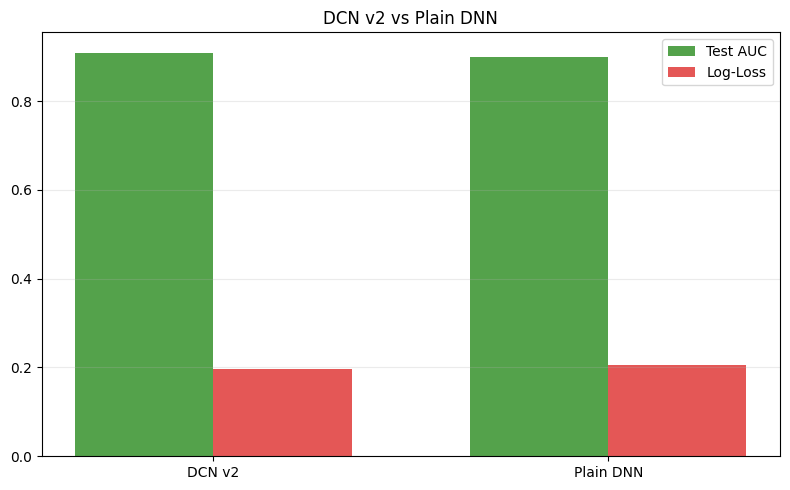

In [16]:
# === STUDENT TODO: Section 4.4 Train & Evaluate ===
import torch.optim as optim
from sklearn.metrics import roc_auc_score, log_loss

def train_ranker(model, train_loader, test_loader, epochs=5):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(epochs):
        model.train(); total_loss = 0; n_batches = 0
        for user_ids, item_ids, dense_feats, labels in train_loader:
            user_ids, item_ids = user_ids.to(device), item_ids.to(device)
            dense_feats, labels = dense_feats.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(user_ids, item_ids, dense_feats)
            loss = criterion(logits, labels.float())
            loss.backward(); optimizer.step()
            total_loss += loss.item(); n_batches += 1
        print(f"  Epoch {epoch+1}/{epochs} - Loss: {total_loss / max(n_batches, 1):.4f}")
    model.eval(); y_true, y_prob = [], []
    with torch.no_grad():
        for user_ids, item_ids, dense_feats, labels in test_loader:
            logits = model(user_ids.to(device), item_ids.to(device), dense_feats.to(device))
            probs = torch.sigmoid(logits).cpu().numpy()
            y_prob.extend(probs.tolist()); y_true.extend(labels.numpy().tolist())
    eps = 1e-7
    y_prob = np.clip(np.array(y_prob), eps, 1 - eps)
    auc = roc_auc_score(y_true, y_prob)
    ll = log_loss(y_true, y_prob)
    return auc, ll

dcn_model = DCNv2(num_users_dcn, num_items_dcn, dense_dim, cross_layers=NUM_CROSS_LAYERS).to(device)
plain_dnn_model = PlainDNN(num_users_dcn, num_items_dcn, dense_dim).to(device)
print("Training DCN v2")
dcn_auc, dcn_logloss = train_ranker(dcn_model, train_loader_dcn, test_loader_dcn, epochs=5)
print("Training Plain DNN")
dnn_auc, dnn_logloss = train_ranker(plain_dnn_model, train_loader_dcn, test_loader_dcn, epochs=5)
comparison = pd.DataFrame({'model': ['DCN v2', 'Plain DNN'], 'Test AUC': [dcn_auc, dnn_auc], 'Log-Loss': [dcn_logloss, dnn_logloss]})
print("\nDCN vs Plain DNN comparison:")
print(comparison.to_string(index=False))
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(comparison['model'])); width = 0.35
ax.bar(x - width/2, comparison['Test AUC'], width, label='Test AUC', color='#54A24B')
ax.bar(x + width/2, comparison['Log-Loss'], width, label='Log-Loss', color='#E45756')
ax.set_xticks(x); ax.set_xticklabels(comparison['model']); ax.set_title('DCN v2 vs Plain DNN')
ax.legend(); ax.grid(axis='y', alpha=0.25); plt.tight_layout(); plt.show()


### 4.5: Cross Layer Ablation Study
**STUDENT TODO:**
Re-initialize the DCN v2 sequentially using an ablation configuration modifying the absolute number of stacked cross layers (1 layer, 2 layers, 4 layers). Validate to verify if increasing mathematical explicit cross intersection depth materially augments standard ROC predictive limits.


In [17]:
# === STUDENT TODO: Section 4 Ablation ===
print("STEP 4.5 — CROSS LAYER ABLATION")
ablation_results = []
for n_layers in [1, 2, 4]:
    print(f"\nTraining DCN with {n_layers} cross layer(s)")
    model = DCNv2(num_users_dcn, num_items_dcn, dense_dim, cross_layers=n_layers).to(device)
    auc, ll = train_ranker(model, train_loader_dcn, test_loader_dcn, epochs=5)
    ablation_results.append((n_layers, auc, ll))

print(f"\n{'='*50}")
print(f"  {'Layers':>8} {'AUC':>10} {'Log-Loss':>12}")
print(f"  {'-'*30}")
for n, auc, ll in ablation_results:
    print(f"  {n:>8} {auc:>10.4f} {ll:>12.4f}")
print(f"  {'(DNN)':>8} {dnn_auc:>10.4f} {dnn_logloss:>12.4f}")
best_layers, best_auc, best_ll = max(ablation_results, key=lambda x: x[1])
print(f"\nConclusion: The best DCN configuration by AUC used {best_layers} cross layer(s), with AUC={best_auc:.4f} and log-loss={best_ll:.4f}.")
print("Deeper cross networks only help if the extra explicit feature interactions generalize; otherwise they can add variance and may not beat the shallower or plain DNN model.")


STEP 4.5 — CROSS LAYER ABLATION

Training DCN with 1 cross layer(s)


  Epoch 1/5 - Loss: 0.4736


  Epoch 2/5 - Loss: 0.2893


  Epoch 3/5 - Loss: 0.2121


  Epoch 4/5 - Loss: 0.1716


...

  Epoch 1/5 - Loss: 0.4857


  Epoch 2/5 - Loss: 0.2513


  Epoch 3/5 - Loss: 0.1874


  Epoch 4/5 - Loss: 0.1582


  Epoch 5/5 - Loss: 0.1388

    Layers        AUC     Log-Loss
  ------------------------------
         1     0.9045       0.2081
         2     0.9044       0.1996
         4     0.9005       0.2056
     (DNN)     0.8988       0.2045

Conclusion: The best DCN configuration by AUC used 1 cross layer(s), with AUC=0.9045 and log-loss=0.2081.
Deeper cross networks only help if the extra explicit feature interactions generalize; otherwise they can add variance and may not beat the shallower or plain DNN model.


---
## Section 5: YouTube Recommendations Short Answers

**(a)** Covington et al. handled freshness by adding an example-age feature during training. The model learned the bias associated with how old an example was, and at serving time that feature was set to zero, which corrected the learned tendency to over-favor older videos with more accumulated watch history.

**(b)** YouTube optimized expected watch time rather than raw CTR. They trained with weighted logistic regression where positive impressions were weighted by observed watch time and negative impressions received unit weight; the resulting odds approximate expected watch time per impression instead of only click probability.

## AI Assistance Prompts Used

- "complete bax423 homework 6 recommendation systems notebook and writeup"
- "download food com raw interactions and raw recipes csv into archive folder"
- "use my uc davis id 925678478 for solo deterministic seed parameters"
- "build surprise collaborative filtering baselineonly svd and three times latent factors"
- "build two tower pytorch model with faiss recall latency nprobe sweep"
- "build dcn v2 ranker compare plain dnn and cross layer ablation"
- "answer youtube recommendations paper freshness and watch time weighting"
- "package notebook writeup ai prompts and screenshots into homework 6 zip"

